Primero calculo la media y la desviación estandar para una v

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# *************************Calculo la presion media*****************************

presion_1=np.loadtxt("Presion_v_3.txt")
presion_2=np.loadtxt("Presion_v_3_1.txt")
presion_3=np.loadtxt("Presion_v_3_2.txt")

Presion_1_media = np.mean(presion_1[50000:])
Presion_2_media = np.mean(presion_2[50000:])
Presion_3_media = np.mean(presion_3[50000:])

presion_media = np.mean([Presion_1_media, Presion_2_media, Presion_3_media])
desviacion = np.std([Presion_1_media, Presion_2_media, Presion_3_media])

#*********************************Calculo la temperatura media*****************************

def T_media(v_x, v_y):

    # Hago la media sobre las columnas, es decir, sobre los átomos, para obtener la temperatura en cada instante de tiempo 
    T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1) 

    # Hago la media sobre el tiempo para obtener la temperatura media
    T = np.mean(T)

    return T

velocidades_1 = np.loadtxt("Velocidades_atomos_v_3.txt")
velocidades_2 = np.loadtxt("Velocidades_atomos_v_3_1.txt")
velocidades_3 = np.loadtxt("Velocidades_atomos_v_3_2.txt")

v_x_1 = velocidades_1[50000:, 0::2]
v_y_1 = velocidades_1[50000:, 1::2]
v_x_2 = velocidades_2[50000:, 0::2]
v_y_2 = velocidades_2[50000:, 1::2]
v_x_3 = velocidades_3[50000:, 0::2]
v_y_3 = velocidades_3[50000:, 1::2]

T_1_1 = T_media(v_x_1, v_y_1)
T_1_2 = T_media(v_x_2, v_y_2)
T_1_3 = T_media(v_x_3, v_y_3)

T_m=np.mean([T_1_1, T_1_2, T_1_3])
desviacion_T=np.std([T_1_1, T_1_2, T_1_3])

print("La presion media es: ", presion_media, " +/- ", desviacion)
print("La temperatura media es: ", T_m, " +/- ", desviacion_T)


La presion media es:  0.69365346508  +/-  0.003539306555879486
La temperatura media es:  4.490117020051692  +/-  0.0240178771828971


Representación de valores obtenidos

=== ANÁLISIS DE PENDIENTES ===
Pendiente de la simulación (m): 0.15513


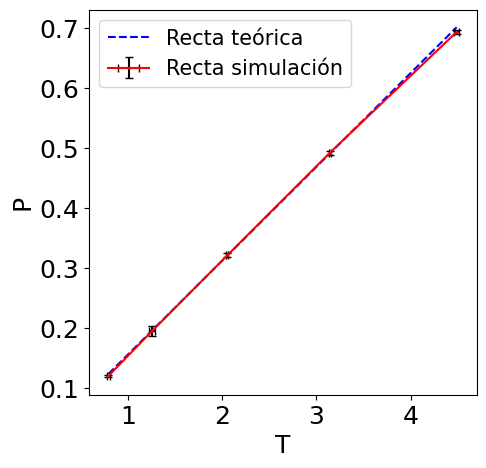

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Almaceno las presiones medias en un array
Presion = np.array([0.12012612675555556, 0.1951845983511111, 0.32147617080888885, 0.4923220340266667,  0.69365346508])
T = np.array([0.7906003961029802, 1.2542306135575114, 2.05435686151707, 3.143046900176824, 4.490117020051692])
# 1. Define los arrays con los errores de cada variable (Sustituye por tus datos reales)
error_T = np.array([0.0186179246928748, 0.03391596843436637, 0.010785436036731957, 0.010222945889763359, 0.0240178771828971])  # Ejemplo de incertidumbre en la Temperatura
error_P = np.array([0.001979671443665475, 0.008729621470855648, 0.003292343431253981, 0.0029926816032183764, 0.003539306555879486]) # Ejemplo de incertidumbre en la Presión

# Hago el gráfico de la presión en función de la temperatura
fig, ax = plt.subplots(figsize = (5, 5))



# 3. Calculamos la Presión teórica del gas ideal y la graficamos
Presion_teorica = (160 / (32**2)) * T
m, n = np.polyfit(T, Presion, 1)

print("=== ANÁLISIS DE PENDIENTES ===")
print(f"Pendiente de la simulación (m): {m:.5f}")

ax.plot(T, Presion_teorica, color="blue", linestyle="--", label="Recta teórica")
ax.errorbar(T, Presion, xerr=error_T, yerr=error_P,fmt='o-', color="red",ecolor="black",capsize=3, markersize=1, label="Recta simulación")        
ax.set_xlabel("T", fontsize=18)
ax.set_ylabel("P", fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.legend(fontsize=15)

fig.savefig("Presion_vs_Temperatura_ej_3.png", dpi = 300)
plt.show()


